In [1]:
# Pour la manipulation de tableaux et Dataframes
import numpy as np
import pandas as pd

# Pour la visualisation des performances
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Pour instancier une couche Dense et modèle séquentiel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from pathlib import Path
DATA_DIR = Path("/app/data")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# Les colonnes ne sont pas nommées dans le fichier brut de l'UCI
colnames = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_df = pd.read_csv(url, names=colnames)
# Sauvegarde dans un fichier CSV
# iris_df.to_csv(str(DATA_DIR / "iris_data.csv"), index=False)
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
from sklearn.datasets import load_iris
iris = load_iris()
X1, y1 = iris.data, iris.target
print("X")
print(X1)
print("y")
print(y1)

X
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 

In [6]:
X = iris_df.drop(columns='species')
y = iris_df['species']
print(y)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=1/3, random_state=42)

L’entraînement d’un réseau de neurones se déroule, pour faire simple, en trois étapes principales :

##### Etape 1 : Définition de l’```architecture du modèle```
	nombre de couche et de neurones et comment les données passeront à travers le réseau

##### Etape 2 : ```Compilation``` du modèle
	- la fonction de perte => la qualité de la prédiction (mésure l'erreur entre la pred et le réel)
	- métriques => évaluer les performances
	- algorithme d'optimisation => ajuster les poids pour réduire l'erreur

##### Etape 3 : ```Entraînement``` du modèle : utiliser la méthode fit

Ces étapes constituent le cœur du processus d’entraînement d’un réseau de neurones.

#### Etape 1 : Définition de l’architecture du modèle

In [9]:
# Création du modèle séquentiel
model = Sequential()

# On définit d'abord la forme de l'entrée
model.add(Input(shape=(4,)))

# Ajout des couches dans l'ordre
model.add(Dense(units=10, activation="tanh"))
model.add(Dense(units=8, activation="tanh"))
model.add(Dense(units=6, activation="tanh"))
model.add(Dense(units=3, activation="softmax"))

In [10]:
## Affichez la structure du modèle en utilisant la méthode summary
model.summary()
# On peut observer le nombre de paramètres que le modèle doit apprendre, 
# c'est-à-dire le nombre de poids qu'il doit ajuster lors de l'entraînement à l'aide de la descente de gradient.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213 (852.00 B)

 Trainable params: 213 (852.00 B)

 Non-trainable params: 0 (0.00 B)

On peut observer le nombre de paramètres que le modèle doit apprendre, c'est-à-dire le nombre de poids qu'il doit ajuster lors de l'entraînement à l'aide de la descente de gradient.
#### D'où viennent les chiffres dans Param # ?
La formule mathématique pour calculer le nombre de paramètres d'une couche Dense est : 
``Paramètres = (entrées x nb_neurones) + nb_neurones``
<br> exemple : 
     <ul>
     <li>50 = (4 x 10) + 10</li>
     <li>88 = (10 x 8) + 8</li>
     <li>54 = (8 x 6) + 6</li>
     <li>21 = (6 x 3) + 3</li>
    </ul>     

#### Etape 2 : Compilation du modèle

In [11]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer="adam",
             metrics=["accuracy"])

#### 1. loss="sparse_categorical_crossentropy" (La fonction de perte)
    <ul>
        <li>Pourquoi "Categorical Crossentropy" ? Parce que tu fais de la classification</li>
        <li>Pourquoi "Sparse" ? tes étiquettes (les réponses attendues dans tes données) sont de simples nombres entiers (par exemple : 0 pour "Chat", 1 pour "Chien", 2 pour "Oiseau"). Si tu n'avais pas mis sparse, tu aurais dû encoder tes réponses sous forme de vecteurs (ex: [1, 0, 0]), ce qu'on appelle le One-Hot Encoding.</li>
    </ul>


#### Etape 3 : Entraînement du modèle

In [12]:
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.1)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3333 - loss: 1.1978 - val_accuracy: 0.4000 - val_loss: 1.0972
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.1614 - val_accuracy: 0.4000 - val_loss: 1.0800
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.1286 - val_accuracy: 0.4000 - val_loss: 1.0663
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.0999 - val_accuracy: 0.4000 - val_loss: 1.0551
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.0783 - val_accuracy: 0.4000 - val_loss: 1.0469
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3333 - loss: 1.0580 - val_accuracy: 0.4000 - val_loss: 1.0398
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3333 - loss: 1.0398 - val_accuracy: 0.4000 - val_loss: 1.0326
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3556 - loss: 1.0233 - val_accuracy: 0.4000 - val_loss:

#### validation_split=0.1 (Le test surprise)

C'est une excellente pratique ! Tu demandes à Keras de mettre de côté 10 % de tes données d'entraînement et de ne surtout pas s'entraîner dessus.

    À la fin de chaque époque, le modèle va passer un "examen" sur ces 10 % de données cachées.

    Cela va te donner deux types de scores dans ta console : l'accuracy sur les données d'entraînement (accuracy) et l'accuracy sur les données de validation (val_accuracy).

    Si ton accuracy monte à 98% mais que ta val_accuracy stagne à 60%, c'est le signe que ton modèle apprend par cœur (overfitting).

#### 1. Décryptage des scores (Époque 500)

    accuracy: 0.9889 (98,89 %) : Sur tes données d'entraînement, le modèle classe correctement près de 99 % des exemples. Il ne se trompe presque jamais.

    loss: 0.0622 : L'erreur globale est très proche de 0. C'est le signe que l'optimiseur a fait du très bon travail.

    val_accuracy: 1.0000 (100 %) : C'est le score parfait. Sur les données de validation (les données "surprises" qu'il n'a pas vues pendant l'entraînement), le modèle a fait un sans-faute.

    val_loss: 0.0239 : La perte de validation est extrêmement basse, encore plus basse que celle d'entraînement, ce qui confirme que le modèle est très stable.

#### 2. Le verdict : Pas de surapprentissage (Overfitting) !

C'était le piège avec 500 époques, mais ton modèle l'a brillamment évité. On parle de surapprentissage lorsque l'accuracy d'entraînement est excellente (ex: 99 %) mais que l'accuracy de validation s'effondre (ex: 70 %).

Ici, les deux scores (accuracy et val_accuracy) sont très proches et très hauts. Ton modèle n'a pas bêtement appris tes données par cœur, il a réellement compris la logique générale de ton problème.

### Performances du modèle

le modèle a 3 neurones de sortie avec une activation softmax. 
<br>model.add(Dense(units=3, activation="softmax"))

#### Étape 1 : Ce que renvoie model.predict(X_test)
Quand tu écris **test_pred = model.predict(X_test)**, le modèle ne te dit pas directement "C'est la classe 0" ou "C'est la classe 2". 
À cause du softmax, il te donne des probabilités.
Pour un échantillon donné, **test_pred** va ressembler à ça : 
``[0.1, 0.05, 0.85]``

<ul>
    <li>Indice 0 : 10% de chance que ce soit la classe 0</li>
    <li>Indice 1 : 5% de chance que ce soit la classe 1</li>
    <li>Indice 2 : 85% de chance que ce soit la classe 2</li>
</ul>

#### Étape 2 : Le problème avec la Matrice de Confusion

Pour afficher une matrice de confusion, Scikit-Learn veut comparer des choses comparables.
<br>Il veut que tu lui donnes :<br>

 - **y_test** (les vraies classes). 
<br>exemple dans notre cas c'est : 
<blockquote>array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 2, 2, 1, 2])</blockquote>

 - **test_pred** (tes prédictions)
   sauf qu'actuellement tu as :
   <blockquote>array([[4.09831153e-03, 9.93738472e-01, 2.16315011e-03],
       [9.93037939e-01, 6.91453926e-03, 4.76342539e-05],...,[5.65212795e-05, 7.64427008e-03, 9.92299259e-01]])</blockquote>

Si tu lui donnes ça, Scikit-Learn va planter.

#### Étape 3 : La solution avec np.argmax()

Pour passer du vecteur de probabilités `[0.1, 0.05, 0.85]` à l'entier `2`, on utilise la fonction **np.argmax()**.
<br>Son rôle est très simple : 
<br>elle **cherche la valeur la plus grande** dans le tableau et **te renvoie son indice (sa position)**.

Ici, la plus grande valeur est 0.85. Elle se trouve à la position 2 (en partant de 0). Donc np.argmax va te renvoyer 2

#### Concrètement, voici ce que tu dois écrire dans ton code

In [16]:
# 1. Tu récupères les probabilités
test_pred_prob = model.predict(X_test)

# 2. Tu transformes les probabilités en numéros de classes (0, 1, ou 2)
test_pred_classes = np.argmax(test_pred_prob, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



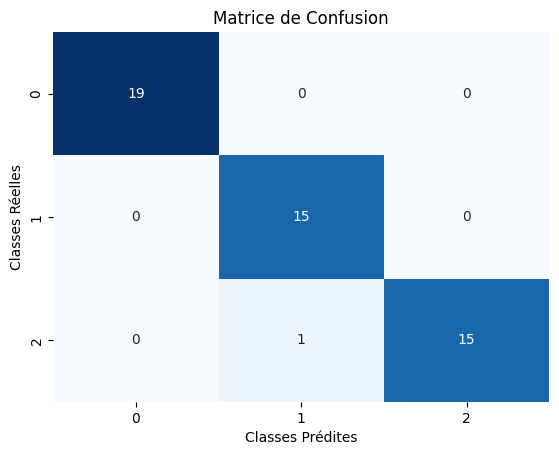

In [21]:
# 3. Maintenant tu peux utiliser scikit-learn !
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, test_pred_classes))
sns.heatmap(confusion_matrix(y_test, test_pred_classes), cmap='Blues', cbar=False, annot=True)
plt.xlabel("Classes Prédites")
plt.ylabel("Classes Réelles")
plt.title("Matrice de Confusion") # Optionnel : pour ajouter un titre en haut

plt.show() # Pour afficher proprement le graphique

#### Voici comment lire et interpréter ces deux résultats de manière très simple.

1. Analyse de la **Matrice de Confusion (le graphique bleu)**

La règle d'or pour une matrice de confusion : 
<br>**plus la grande diagonale (du haut gauche au bas droit) est foncée et remplie, meilleur est le modèle.** 
<br>Tout ce qui est en dehors de cette diagonale représente des erreurs.

Regardons tes 50 échantillons de test :

<ul>
    <li>Classe 0 : Il y en avait 19. Le modèle a trouvé les 19. Zéro erreur.</li>
    <li>Classe 1 : Il y en avait 15. Le modèle a trouvé les 15. Zéro erreur.</li>
    <li>Classe 2 : Il y en avait 16. Le modèle en a trouvé 15... et s'est trompé sur 1 seul échantillon, qu'il a classé par erreur dans la classe 1.</li>
</ul>
    

2. Analyse du **classification_report (le texte)**
Ce tableau traduit les cases de ta matrice de confusion en métriques mathématiques :
- Support : C'est le nombre total d'éléments réels de chaque classe dans ton jeu de test ($19 + 15 + 16 = 50$).
- Precision (Fiabilité) : Quand le modèle dit "C'est la classe X", est-ce qu'il a raison ?
    - Pour la classe 1, sa précision est de 0.94. Pourquoi ? Parce qu'il a prédit 16 fois la classe 1 (les 15 vrais + le rescapé de la classe 2), mais seulement 15 étaient corrects ($\frac{15}{16} = 93.75\%$).
- Recall / Sensibilité (Taux de détection) : Sur tous les vrais éléments d'une classe, combien le modèle a-t-il réussi à en capturer ?
    - Pour la classe 2, son recall est de 0.94 parce qu'il a raté 1 élément sur les 16 existants ($\frac{15}{16} = 93.75\%$).
- F1-Score : C'est un juste milieu (une moyenne) entre la Precision et le Recall. Proche de 1, c'est parfait. Ici, tes scores balancent entre 0.97 et 1.00.

#### En résumé
Ton réseau de neurones a confondu une seule fois un élément de la classe 2 en pensant que c'était la classe 1. Pour tout le reste, il a vu parfaitement juste. Tu as un modèle robuste et prêt à l'emploi !

In [23]:
## Pour avoir les noms des classes
nom_des_classes = encoder.classes_
print(nom_des_classes)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


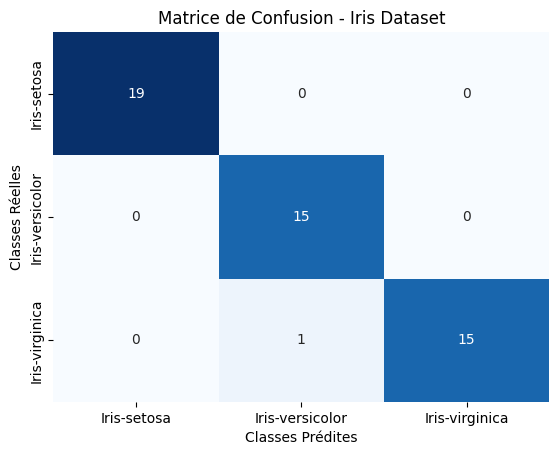

In [24]:
sns.heatmap(
    confusion_matrix(y_test, test_pred_classes), 
    cmap='Blues', 
    cbar=False, 
    annot=True,
    xticklabels=nom_des_classes, # Axe X : Setosa, Versicolor, Virginica
    yticklabels=nom_des_classes  # Axe Y : Setosa, Versicolor, Virginica
)

plt.xlabel("Classes Prédites")
plt.ylabel("Classes Réelles")
plt.title("Matrice de Confusion - Iris Dataset")
plt.show()

#### afficher l'évolution de la loss au fil des époques

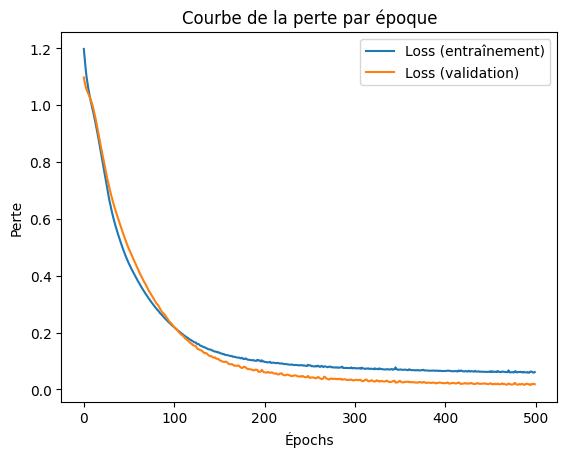

In [25]:
plt.figure()
plt.plot(history.history['loss'], label='Loss (entraînement)')
plt.plot(history.history['val_loss'], label='Loss (validation)')
plt.title('Courbe de la perte par époque')
plt.xlabel('Épochs')
plt.ylabel('Perte')
plt.legend()
plt.show()

### Ce qu'il faut retenir
- L'algorithme du perceptron multicouche (MLP) est particulièrement efficace pour les problèmes de classification.
- Pour un problème de classification multi-classe, on utilise généralement la fonction de perte sparse_categorical_crossentropy, qui convient aux labels encodés sous forme d'entiers.
- On peut construire un MLP de manière simple avec Keras en utilisant une approche séquentielle, adaptée pour des architectures linéaires. La méthode fonctionnelle, bien que plus complexe à maîtriser, offre une flexibilité accrue, notamment pour des architectures avancées
- L'entraînement du réseau de neurones est contrôlé par deux paramètres principaux : batch_size, qui détermine le nombre d'échantillons traités par étape, et epochs, qui indique le nombre de fois que l'ensemble des données est parcouru pendant l'apprentissage.
